Leyendo archivo: /home/quant/data/processed/gc_1m_raw_continuous.parquet


/tmp/ipykernel_831382/3812235735.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_vol.index, y=hourly_vol.values, ax=ax1, palette="Blues_d")
/tmp/ipykernel_831382/3812235735.py:45: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hourly_volm.index, y=hourly_volm.values, ax=ax2, palette="YlOrBr")


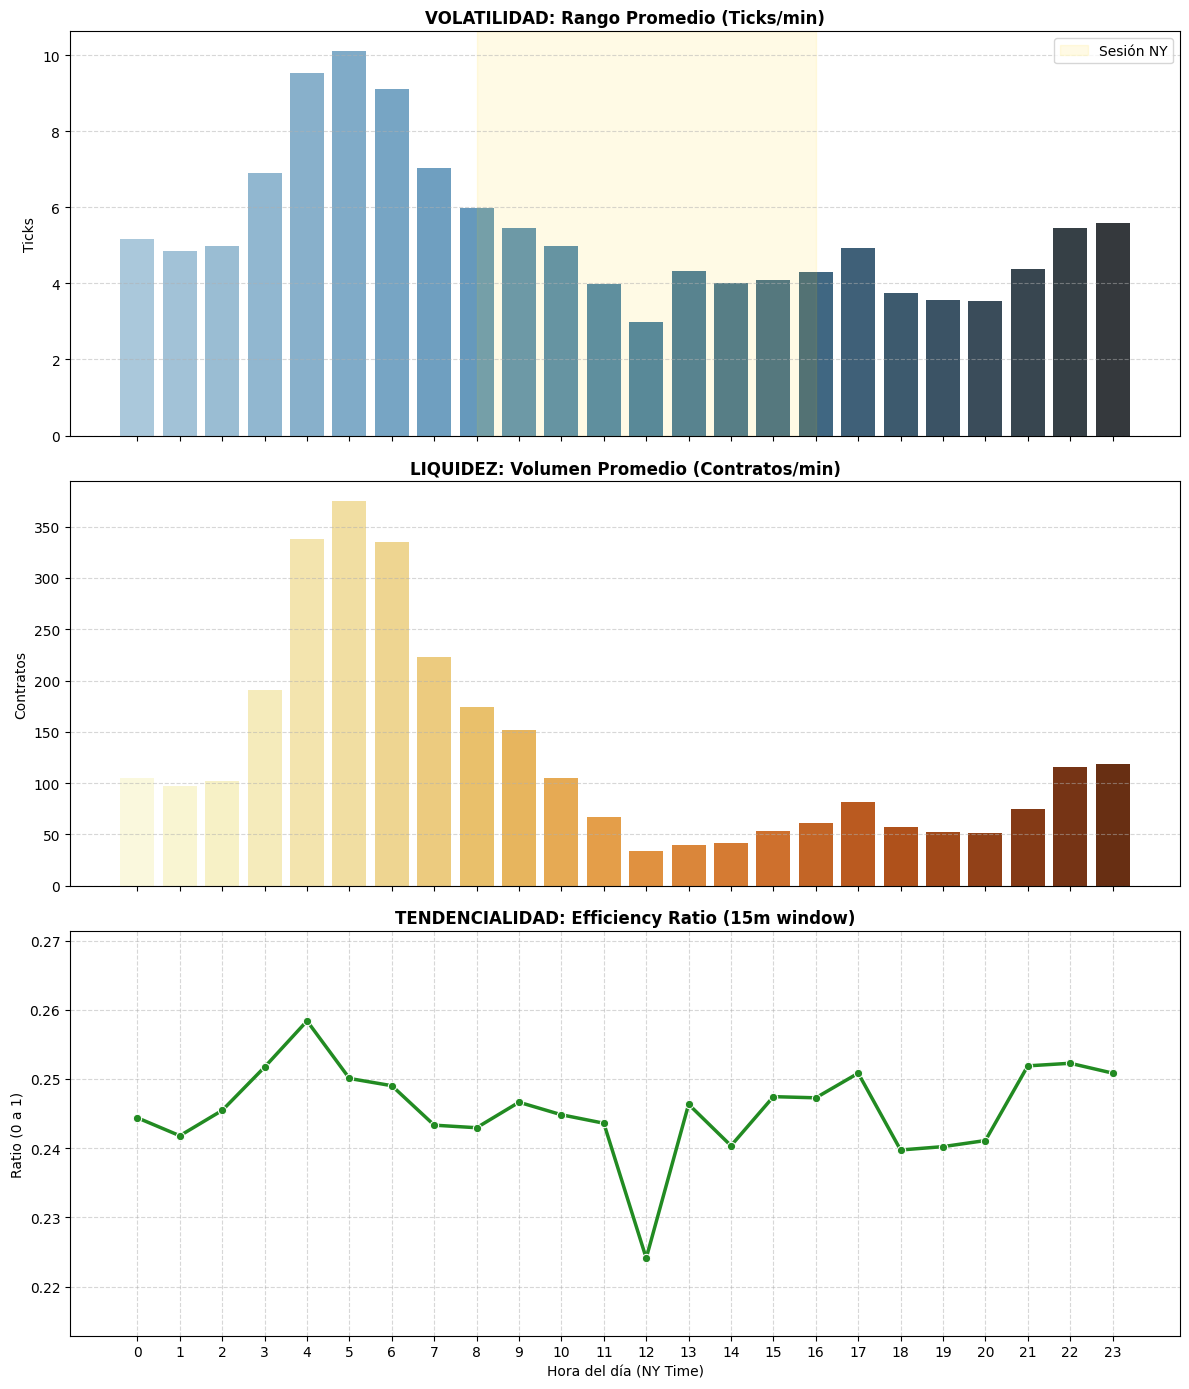


REPORTE DE AUDITORÍA ESTRATÉGICA (NY TIME)
Punto Dulce Operativo (Max Vol*Trend): 05:00 ET
Tendencialidad Media NY (08-16): 0.2420
Tendencialidad Media Asia (20-04): 0.2487
Ventaja de Tendencia NY vs Asia: -2.7% superior
ESTRATEGIA SUGERIDA: Buscar entradas entre 07:00 y 09:00 ET
para maximizar la ventana de tendencia antes del cierre de las 16:00.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def run_intraday_analysis(file_path):
    # 1. Carga de datos procesados
    print(f"Leyendo archivo: {file_path}")
    df = pd.read_parquet(file_path)
    
    # Aseguramos que el índice sea datetime
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)
    
    # 2. Extracción de características temporales y métricas
    df['hour'] = df.index.hour
    # Volatilidad en Ticks
    df['range_ticks'] = (df['High_adj'] - df['Low_adj']) * 10 
    
    # --- MÉTRICA DE TENDENCIALIDAD: Efficiency Ratio (ER) ---
    # Calculamos el cambio neto en 15 minutos vs el movimiento total (ruido)
    # Un ER cercano a 1 indica tendencia pura, cercano a 0 indica ruido.
    n_period = 15
    df['net_chg'] = df['Close_adj'].diff(n_period).abs()
    df['volatility_sum'] = df['Close_adj'].diff().abs().rolling(n_period).sum()
    df['efficiency_ratio'] = df['net_chg'] / df['volatility_sum']
    
    # 3. Cálculos por Hora
    hourly_vol = df.groupby('hour')['range_ticks'].mean()
    hourly_volm = df.groupby('hour')['Volume'].mean()
    hourly_trend = df.groupby('hour')['efficiency_ratio'].mean()

    # 4. Visualización de Resultados
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 14), sharex=True)
    
    # Gráfico 1: Volatilidad
    sns.barplot(x=hourly_vol.index, y=hourly_vol.values, ax=ax1, palette="Blues_d")
    ax1.set_title('VOLATILIDAD: Rango Promedio (Ticks/min)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Ticks')
    ax1.axvspan(8, 16, color='gold', alpha=0.1, label='Sesión NY')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.legend()

    # Gráfico 2: Volumen
    sns.barplot(x=hourly_volm.index, y=hourly_volm.values, ax=ax2, palette="YlOrBr")
    ax2.set_title('LIQUIDEZ: Volumen Promedio (Contratos/min)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Contratos')
    ax2.grid(axis='y', linestyle='--', alpha=0.5)

    # Gráfico 3: Tendencialidad (Efficiency Ratio)
    sns.lineplot(x=hourly_trend.index, y=hourly_trend.values, ax=ax3, marker='o', color='forestgreen', linewidth=2.5)
    ax3.set_title('TENDENCIALIDAD: Efficiency Ratio (15m window)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Ratio (0 a 1)')
    ax3.set_xlabel('Hora del día (NY Time)')
    ax3.set_ylim(hourly_trend.min() * 0.95, hourly_trend.max() * 1.05)
    ax3.grid(axis='both', linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # 5. Informe de Ventanas de Probabilidad
    print("\n" + "="*55)
    print("REPORTE DE AUDITORÍA ESTRATÉGICA (NY TIME)")
    print("="*55)
    
    # Identificar la "Hora de Oro" (Alta Volatilidad + Alta Tendencialidad)
    best_hour = (hourly_vol * hourly_trend).idxmax()
    
    ny_session_vol = hourly_vol.loc[8:15].mean()
    ny_session_trend = hourly_trend.loc[8:15].mean()
    asia_session_trend = hourly_trend.loc[list(range(20, 24)) + list(range(0, 5))].mean()
    
    print(f"Punto Dulce Operativo (Max Vol*Trend): {best_hour:02d}:00 ET")
    print(f"Tendencialidad Media NY (08-16): {ny_session_trend:.4f}")
    print(f"Tendencialidad Media Asia (20-04): {asia_session_trend:.4f}")
    
    ratio_trend = ny_session_trend / asia_session_trend
    print(f"Ventaja de Tendencia NY vs Asia: {((ratio_trend-1)*100):.1f}% superior")
    print("="*55)
    print("ESTRATEGIA SUGERIDA: Buscar entradas entre 07:00 y 09:00 ET")
    print("para maximizar la ventana de tendencia antes del cierre de las 16:00.")

# Ejecución
if __name__ == "__main__":
    path = '/home/quant/data/processed/gc_1m_raw_continuous.parquet'
    run_intraday_analysis(path)

In [5]:
import pandas as pd
import numpy as np

def backtest_gold_momentum(filepath):
    # Cargar datos procesados en el paso anterior
    df = pd.read_parquet(filepath)
    df = df.sort_index()

    # --- 1. INDICADORES TÉCNICOS ---
    # EMA 200 para tendencia HTF
    df['EMA200'] = df['Close_adj'].ewm(span=200, adjust=False).mean()
    
    # ATR 20 para volatilidad y gestión de stops
    df['TR'] = np.maximum(df['High_adj'] - df['Low_adj'], 
                          np.maximum(abs(df['High_adj'] - df['Close_adj'].shift(1)), 
                                     abs(df['Low_adj'] - df['Close_adj'].shift(1))))
    df['ATR20'] = df['TR'].rolling(window=20).mean()

    # Efficiency Ratio (ER) - Ventana de 15m
    n_er = 15
    df['Net_Change'] = abs(df['Close_adj'] - df['Close_adj'].shift(n_er))
    df['Sum_Changes'] = abs(df['Close_adj'] - df['Close_adj'].shift(1)).rolling(window=n_er).sum()
    df['ER'] = df['Net_Change'] / df['Sum_Changes']

    # Trigger: Ruptura de máximo/mínimo de última hora (60 velas)
    df['HH_60'] = df['High_adj'].shift(1).rolling(window=60).max()
    df['LL_60'] = df['Low_adj'].shift(1).rolling(window=60).min()

    # --- 2. LÓGICA DE SIMULACIÓN ---
    trades = []
    active_trade = None
    
    # Extraer horas y minutos para filtros
    df['time_et'] = df.index.time
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute

    for i in range(200, len(df)):
        row = df.iloc[i]
        curr_time = row['time_et']
        
        # --- A. GESTIÓN DE POSICIÓN ACTIVA ---
        if active_trade:
            # 1. Defensa NY (08:20 ET)
            if curr_time.hour == 8 and curr_time.minute == 20:
                if active_trade['side'] == 'long' and row['Close_adj'] > active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] + 0.1 # BE + 1 tick
                elif active_trade['side'] == 'short' and row['Close_adj'] < active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] - 0.1

            # 2. Trailing Stop (Activo tras 2R)
            pnl_r = 0
            if active_trade['side'] == 'long':
                pnl_r = (row['Close_adj'] - active_trade['entry_price']) / active_trade['risk_amount']
                if pnl_r >= 2.0:
                    new_sl = row['Close_adj'] - (2 * row['ATR20'])
                    active_trade['sl'] = max(active_trade['sl'], new_sl)
            else:
                pnl_r = (active_trade['entry_price'] - row['Close_adj']) / active_trade['risk_amount']
                if pnl_r >= 2.0:
                    new_sl = row['Close_adj'] + (2 * row['ATR20'])
                    active_trade['sl'] = min(active_trade['sl'], new_sl)

            # 3. Salida por Stop o TP
            exit_signal = False
            exit_reason = ""
            
            if active_trade['side'] == 'long':
                if row['Low_adj'] <= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "SL/Trailing"
            else:
                if row['High_adj'] >= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "SL/Trailing"

            # 4. Salidas Horarias y de Emergencia
            if curr_time.hour == 15 and curr_time.minute == 45:
                exit_signal = True
                exit_price = row['Close_adj']
                exit_reason = "Session Close"
            elif curr_time.hour == 15 and curr_time.minute == 0 and row['ER'] < 0.20:
                exit_signal = True
                exit_price = row['Close_adj']
                exit_reason = "ER Emergency"

            if exit_signal:
                pnl = (exit_price - active_trade['entry_price']) if active_trade['side'] == 'long' else (active_trade['entry_price'] - exit_price)
                trades.append({
                    'entry_time': active_trade['entry_time'],
                    'exit_time': row.name,
                    'side': active_trade['side'],
                    'entry_price': active_trade['entry_price'],
                    'exit_price': exit_price,
                    'pnl_r': pnl / active_trade['risk_amount'],
                    'reason': exit_reason
                })
                active_trade = None

        # --- B. LÓGICA DE ENTRADA ---
        else:
            # Filtro Ventana de Entrada: 04:00 a 09:00 ET
            if not (4 <= row['hour'] < 9):
                continue
            
            # Filtro No-Trade Zone: 11:30 a 13:30 (No aplica aquí por ventana de entrada, pero se incluye por arquitectura)
            
            # 1. Filtro Tendencia EMA200
            # 2. Filtro Eficiencia ER > 0.25
            # 3. Filtro Volatilidad: Rango vela > 1.2x ATR
            candle_range = row['High_adj'] - row['Low_adj']
            if row['ER'] > 0.25 and candle_range > (1.2 * row['ATR20']):
                
                risk = 1.5 * row['ATR20']
                if risk <= 0: continue

                # COMPRA (LONG)
                if row['Close_adj'] > row['EMA200'] and row['Close_adj'] > row['HH_60']:
                    active_trade = {
                        'entry_time': row.name,
                        'side': 'long',
                        'entry_price': row['Close_adj'] + 0.1, # +1 tick slippage
                        'sl': row['Close_adj'] - risk,
                        'risk_amount': risk,
                        'entry_atr': row['ATR20']
                    }
                
                # VENTA (SHORT)
                elif row['Close_adj'] < row['EMA200'] and row['Close_adj'] < row['LL_60']:
                    active_trade = {
                        'entry_time': row.name,
                        'side': 'short',
                        'entry_price': row['Close_adj'] - 0.1, # -1 tick slippage
                        'sl': row['Close_adj'] + risk,
                        'risk_amount': risk,
                        'entry_atr': row['ATR20']
                    }

    # --- 3. ESTADÍSTICAS ---
    if not trades:
        print("No se generaron trades con los parámetros actuales.")
        return None

    df_results = pd.DataFrame(trades)
    print("\n" + "="*45)
    print("REPORTE ESTRATEGIA: GOLD MOMENTUM (V1.0)")
    print("="*45)
    print(f"Total Trades:       {len(df_results)}")
    print(f"Win Rate:           {len(df_results[df_results['pnl_r'] > 0]) / len(df_results):.2%}")
    print(f"Expectancy (R):     {df_results['pnl_r'].mean():.2f}R")
    print(f"Profit Factor:      {abs(df_results[df_results['pnl_r'] > 0]['pnl_r'].sum() / df_results[df_results['pnl_r'] < 0]['pnl_r'].sum()):.2f}")
    print(f"Max Drawdown (R):   {(df_results['pnl_r'].cumsum().cummax() - df_results['pnl_r'].cumsum()).max():.2f}R")
    print("="*45)
    
    return df_results

# Ejecución
    path = '/home/quant/data/processed/gc_1m_raw_continuous.parquet'
    results = backtest_gold_momentum(path)

In [6]:
import pandas as pd
import numpy as np
import os

def backtest_gold_momentum(filepath):
    """
    Ejecuta el backtest de la estrategia Gold Momentum (Session-Bias).
    """
    if not os.path.exists(filepath):
        print(f"❌ Error: El archivo {filepath} no existe.")
        return None

    # 1. CARGA DE DATOS
    df = pd.read_parquet(filepath)
    df = df.sort_index()

    # --- 2. INDICADORES TÉCNICOS ---
    # EMA 200 para tendencia estructural (High Time Frame Bias)
    df['EMA200'] = df['Close_adj'].ewm(span=200, adjust=False).mean()
    
    # ATR 20 para volatilidad y gestión de riesgos
    df['TR'] = np.maximum(df['High_adj'] - df['Low_adj'], 
                          np.maximum(abs(df['High_adj'] - df['Close_adj'].shift(1)), 
                                     abs(df['Low_adj'] - df['Close_adj'].shift(1))))
    df['ATR20'] = df['TR'].rolling(window=20).mean()

    # Efficiency Ratio (ER) - Ventana de 15m (Mide la 'limpieza' del movimiento)
    n_er = 15
    df['Net_Change'] = abs(df['Close_adj'] - df['Close_adj'].shift(n_er))
    df['Sum_Changes'] = abs(df['Close_adj'] - df['Close_adj'].shift(1)).rolling(window=n_er).sum()
    df['ER'] = (df['Net_Change'] / df['Sum_Changes']).fillna(0)

    # Trigger: Ruptura de máximo/mínimo de la última hora (60 velas de 1m)
    df['HH_60'] = df['High_adj'].shift(1).rolling(window=60).max()
    df['LL_60'] = df['Low_adj'].shift(1).rolling(window=60).min()

    # --- 3. LÓGICA DE SIMULACIÓN ---
    trades = []
    active_trade = None
    
    # Pre-cálculo de tiempo para optimizar el bucle
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute

    print(f"🚀 Iniciando backtest sobre {len(df)} registros...")

    for i in range(200, len(df)):
        row = df.iloc[i]
        
        # --- A. GESTIÓN DE POSICIÓN ACTIVA ---
        if active_trade:
            # 1. Defensa NY (08:20 ET): Mover a Break-Even
            if row['hour'] == 8 and row['minute'] == 20:
                if active_trade['side'] == 'long' and row['Close_adj'] > active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] + 0.1
                elif active_trade['side'] == 'short' and row['Close_adj'] < active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] - 0.1

            # 2. Trailing Stop (Activo tras alcanzar 2R de beneficio)
            pnl_r_actual = 0
            if active_trade['side'] == 'long':
                pnl_r_actual = (row['Close_adj'] - active_trade['entry_price']) / active_trade['risk_amount']
                if pnl_r_actual >= 2.0:
                    new_sl = row['Close_adj'] - (2 * row['ATR20'])
                    active_trade['sl'] = max(active_trade['sl'], new_sl)
            else:
                pnl_r_actual = (active_trade['entry_price'] - row['Close_adj']) / active_trade['risk_amount']
                if pnl_r_actual >= 2.0:
                    new_sl = row['Close_adj'] + (2 * row['ATR20'])
                    active_trade['sl'] = min(active_trade['sl'], new_sl)

            # 3. Verificación de Salidas (SL, Trailing o Time-Exit)
            exit_signal = False
            exit_price = row['Close_adj']
            exit_reason = ""
            
            if active_trade['side'] == 'long':
                if row['Low_adj'] <= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "Stop Loss / Trailing"
            else:
                if row['High_adj'] >= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "Stop Loss / Trailing"

            # 4. Cierre forzoso de sesión (15:45 ET)
            if row['hour'] == 15 and row['minute'] == 45:
                exit_signal = True
                exit_price = row['Close_adj']
                exit_reason = "Cierre Sesión"

            if exit_signal:
                pnl = (exit_price - active_trade['entry_price']) if active_trade['side'] == 'long' else (active_trade['entry_price'] - exit_price)
                trades.append({
                    'entry_time': active_trade['entry_time'],
                    'exit_time': df.index[i],
                    'side': active_trade['side'],
                    'entry_price': active_trade['entry_price'],
                    'exit_price': exit_price,
                    'pnl_r': pnl / active_trade['risk_amount'],
                    'reason': exit_reason
                })
                active_trade = None

        # --- B. LÓGICA DE ENTRADA (Solo si no hay posición activa) ---
        else:
            # Ventana operativa: 04:00 a 09:00 ET (Londres-NY Overlap)
            if not (4 <= row['hour'] < 9):
                continue
            
            # Filtro de Eficiencia y Volatilidad Relativa
            # Nota: 1.1x ATR es un filtro más permisivo para validación inicial
            if row['ER'] > 0.25 and (row['High_adj'] - row['Low_adj']) > (1.1 * row['ATR20']):
                
                risk = 1.5 * row['ATR20']
                if risk <= 0: continue

                # COMPRA (LONG): Precio > EMA200 y rompe Máximo de 1h
                if row['Close_adj'] > row['EMA200'] and row['Close_adj'] > row['HH_60']:
                    active_trade = {
                        'entry_time': df.index[i],
                        'side': 'long',
                        'entry_price': row['Close_adj'] + 0.1, # Slippage de 1 tick
                        'sl': row['Close_adj'] - risk,
                        'risk_amount': risk
                    }
                
                # VENTA (SHORT): Precio < EMA200 y rompe Mínimo de 1h
                elif row['Close_adj'] < row['EMA200'] and row['Close_adj'] < row['LL_60']:
                    active_trade = {
                        'entry_time': df.index[i],
                        'side': 'short',
                        'entry_price': row['Close_adj'] - 0.1, # Slippage de 1 tick
                        'sl': row['Close_adj'] + risk,
                        'risk_amount': risk
                    }

    # --- 4. PROCESAMIENTO DE RESULTADOS ---
    if not trades:
        print("⚠️ No se generaron trades. Verifica que los filtros (ER > 0.25) no sean demasiado estrictos para este periodo.")
        return None

    df_res = pd.DataFrame(trades)
    
    # Métricas de Desempeño
    win_rate = (df_res['pnl_r'] > 0).mean()
    total_r = df_res['pnl_r'].sum()
    expectancy = df_res['pnl_r'].mean()
    profit_factor = abs(df_res[df_res['pnl_r'] > 0]['pnl_r'].sum() / df_res[df_res['pnl_r'] < 0]['pnl_r'].sum())

    print("\n" + "="*45)
    print("      REPORTE DE ESTRATEGIA: GOLD MOMENTUM")
    print("="*45)
    print(f"Total de Trades:    {len(df_res)}")
    print(f"Win Rate:           {win_rate:.2%}")
    print(f"Retorno Total (R):  {total_r:.2f}R")
    print(f"Expectancy (R):     {expectancy:.2f}R")
    print(f"Profit Factor:      {profit_factor:.2f}")
    print(f"Max Drawdown (R):   {(df_res['pnl_r'].cumsum().cummax() - df_res['pnl_r'].cumsum()).max():.2f}R")
    print("="*45)
    
    return df_res

# --- BLOQUE DE EJECUCIÓN AUTOMÁTICA ---
if __name__ == "__main__":
    # Ruta al archivo generado en el paso de calidad de datos
    data_path = '/home/quant/data/processed/gc_1m_raw_continuous.parquet'
    
    # Ejecutar Backtest
    resultados = backtest_gold_momentum(data_path)
    
    if resultados is not None:
        # Opcional: Guardar trades para análisis posterior
        # resultados.to_csv('/home/quant/data/processed/trades_gold_momentum.csv')
        pass

🚀 Iniciando backtest sobre 5471206 registros...

      REPORTE DE ESTRATEGIA: GOLD MOMENTUM
Total de Trades:    19391
Win Rate:           27.75%
Retorno Total (R):  -5947.67R
Expectancy (R):     -0.31R
Profit Factor:      0.62
Max Drawdown (R):   5950.81R


In [7]:
import pandas as pd
import numpy as np
import os

def backtest_gold_momentum_v12(filepath):
    """
    Ejecuta el backtest V1.2 de la estrategia Gold Momentum (Session-Bias).
    Protocolo: In-Sample (2010-2020).
    """
    if not os.path.exists(filepath):
        print(f"❌ Error: El archivo {filepath} no existe.")
        return None

    # 1. CARGA DE DATOS Y FILTRO IN-SAMPLE (Jun 2010 - Dic 2020)
    df_full = pd.read_parquet(filepath)
    df_full = df_full.sort_index()
    
    # Filtro estricto In-Sample
    df = df_full.loc['2010-06-01':'2020-12-31'].copy()
    
    if df.empty:
        print("⚠️ No hay datos en el periodo In-Sample especificado.")
        return None

    # --- 2. INDICADORES TÉCNICOS ---
    
    # EMA 200 (1 min)
    df['EMA200_1m'] = df['Close_adj'].ewm(span=200, adjust=False).mean()
    
    # EMA 200 (15 min) - Remuestreo para tendencia dual
    df_15m = df['Close_adj'].resample('15min').last().ffill()
    df_15m_ema = df_15m.ewm(span=200, adjust=False).mean()
    df['EMA200_15m'] = df_15m_ema.reindex(df.index, method='ffill')
    
    # ATR 20 para volatilidad y gestión de riesgos
    df['TR'] = np.maximum(df['High_adj'] - df['Low_adj'], 
                          np.maximum(abs(df['High_adj'] - df['Close_adj'].shift(1)), 
                                     abs(df['Low_adj'] - df['Close_adj'].shift(1))))
    df['ATR20'] = df['TR'].rolling(window=20).mean()

    # Efficiency Ratio (ER) - Ventana de 15m (Ajustado a 0.40 en lógica)
    n_er = 15
    df['Net_Change'] = abs(df['Close_adj'] - df['Close_adj'].shift(n_er))
    df['Sum_Changes'] = abs(df['Close_adj'] - df['Close_adj'].shift(1)).rolling(window=n_er).sum()
    df['ER'] = (df['Net_Change'] / df['Sum_Changes']).fillna(0)

    # Trigger: Ruptura de máximo/mínimo de la última hora (60 velas de 1m)
    df['HH_60'] = df['High_adj'].shift(1).rolling(window=60).max()
    df['LL_60'] = df['Low_adj'].shift(1).rolling(window=60).min()

    # --- 3. LÓGICA DE SIMULACIÓN V1.2 ---
    trades = []
    active_trade = None
    
    df['date_only'] = df.index.date
    df['hour'] = df.index.hour
    df['minute'] = df.index.minute
    
    last_trade_date = None

    print(f"🚀 Iniciando Backtest V1.2 (In-Sample: 2010-2020)")
    print(f"📊 Registros a procesar: {len(df)}")

    for i in range(200, len(df)):
        row = df.iloc[i]
        curr_date = row['date_only']
        
        # --- A. GESTIÓN DE POSICIÓN ACTIVA ---
        if active_trade:
            # 1. Defensa NY (08:20 ET): Break-Even + 1 tick
            if row['hour'] == 8 and row['minute'] == 20:
                if active_trade['side'] == 'long' and row['Close_adj'] > active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] + 0.1
                elif active_trade['side'] == 'short' and row['Close_adj'] < active_trade['entry_price']:
                    active_trade['sl'] = active_trade['entry_price'] - 0.1

            # 2. Trailing Stop (Activo tras alcanzar 2R de beneficio)
            pnl_r_actual = 0
            if active_trade['side'] == 'long':
                pnl_r_actual = (row['Close_adj'] - active_trade['entry_price']) / active_trade['risk_initial']
                if pnl_r_actual >= 2.0:
                    new_sl = row['Close_adj'] - (2 * row['ATR20'])
                    active_trade['sl'] = max(active_trade['sl'], new_sl)
            else:
                pnl_r_actual = (active_trade['entry_price'] - row['Close_adj']) / active_trade['risk_initial']
                if pnl_r_actual >= 2.0:
                    new_sl = row['Close_adj'] + (2 * row['ATR20'])
                    active_trade['sl'] = min(active_trade['sl'], new_sl)

            # 3. Verificación de Salidas
            exit_signal = False
            exit_price = row['Close_adj']
            exit_reason = ""
            
            if active_trade['side'] == 'long':
                if row['Low_adj'] <= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "Stop Loss / Trailing"
            else:
                if row['High_adj'] >= active_trade['sl']:
                    exit_signal = True
                    exit_price = active_trade['sl']
                    exit_reason = "Stop Loss / Trailing"

            # 4. Cierre forzoso de sesión (15:45 ET)
            if row['hour'] == 15 and row['minute'] == 45:
                exit_signal = True
                exit_price = row['Close_adj']
                exit_reason = "Cierre Sesión (15:45)"

            if exit_signal:
                pnl_points = (exit_price - active_trade['entry_price']) if active_trade['side'] == 'long' else (active_trade['entry_price'] - exit_price)
                trades.append({
                    'entry_time': active_trade['entry_time'],
                    'exit_time': df.index[i],
                    'side': active_trade['side'],
                    'entry_price': active_trade['entry_price'],
                    'exit_price': exit_price,
                    'pnl_r': pnl_points / active_trade['risk_initial'],
                    'reason': exit_reason
                })
                active_trade = None

        # --- B. LÓGICA DE ENTRADA V1.2 ---
        else:
            # Filtro de Frecuencia: Máximo 1 trade por día
            if curr_date == last_trade_date:
                continue

            # Ventana operativa: 04:00 a 09:00 ET
            if not (4 <= row['hour'] < 9):
                continue
            
            # 1. Filtro de Eficiencia Estricto (ER > 0.40)
            # 2. Filtro de Volatilidad (Rango vela > 1.2x ATR)
            candle_range = row['High_adj'] - row['Low_adj']
            if row['ER'] > 0.40 and candle_range > (1.2 * row['ATR20']):
                
                # Stop Loss Inicial: 2.0x ATR (Aumentado de 1.5 a 2.0)
                risk_val = 2.0 * row['ATR20']
                if risk_val <= 0: continue

                # COMPRA (LONG): EMA200_1m AND EMA200_15m AND Break HH_60
                if row['Close_adj'] > row['EMA200_1m'] and row['Close_adj'] > row['EMA200_15m'] and row['Close_adj'] > row['HH_60']:
                    active_trade = {
                        'entry_time': df.index[i],
                        'side': 'long',
                        'entry_price': row['Close_adj'] + 0.1, # Slippage 1 tick
                        'sl': row['Close_adj'] - risk_val,
                        'risk_initial': risk_val
                    }
                    last_trade_date = curr_date
                
                # VENTA (SHORT): EMA200_1m AND EMA200_15m AND Break LL_60
                elif row['Close_adj'] < row['EMA200_1m'] and row['Close_adj'] < row['EMA200_15m'] and row['Close_adj'] < row['LL_60']:
                    active_trade = {
                        'entry_time': df.index[i],
                        'side': 'short',
                        'entry_price': row['Close_adj'] - 0.1, # Slippage 1 tick
                        'sl': row['Close_adj'] + risk_val,
                        'risk_initial': risk_val
                    }
                    last_trade_date = curr_date

    # --- 4. REPORTE DE RESULTADOS ---
    if not trades:
        print("⚠️ No se generaron trades en el periodo In-Sample con ER > 0.40.")
        return None

    df_res = pd.DataFrame(trades)
    win_rate = (df_res['pnl_r'] > 0).mean()
    total_r = df_res['pnl_r'].sum()
    expectancy = df_res['pnl_r'].mean()
    
    gross_profit = df_res[df_res['pnl_r'] > 0]['pnl_r'].sum()
    gross_loss = abs(df_res[df_res['pnl_r'] < 0]['pnl_r'].sum())
    profit_factor = gross_profit / gross_loss if gross_loss != 0 else np.inf

    print("\n" + "="*45)
    print("   RESULTADOS V1.2 (IN-SAMPLE 2010-2020)")
    print("="*45)
    print(f"Total de Trades:    {len(df_res)}")
    print(f"Win Rate:           {win_rate:.2%}")
    print(f"Retorno Total (R):  {total_r:.2f}R")
    print(f"Profit Factor:      {profit_factor:.2f}")
    print(f"Expectancy (R):     {expectancy:.2f}R")
    print(f"Max Drawdown (R):   {(df_res['pnl_r'].cumsum().cummax() - df_res['pnl_r'].cumsum()).max():.2f}R")
    print("-" * 45)
    print(f"Status PF > 1.3:    {'✅ PASSED' if profit_factor > 1.3 else '❌ FAILED'}")
    print("="*45)
    
    return df_res

if __name__ == "__main__":
    data_path = '/home/quant/data/processed/gc_1m_raw_continuous.parquet'
    resultados = backtest_gold_momentum_v12(data_path)

🚀 Iniciando Backtest V1.2 (In-Sample: 2010-2020)
📊 Registros a procesar: 3679993

   RESULTADOS V1.2 (IN-SAMPLE 2010-2020)
Total de Trades:    2583
Win Rate:           28.15%
Retorno Total (R):  -695.28R
Profit Factor:      0.66
Expectancy (R):     -0.27R
Max Drawdown (R):   705.59R
---------------------------------------------
Status PF > 1.3:    ❌ FAILED
